# FleetRL — tổng hợp kết quả train và kiểm thử Study14

**Nguồn:** `runs/study14/algorithm_comparison.csv`, `episodes.csv`, `summary.json`, `plan.json`, `selected_learning.json` và log train trong `jobs/`. Notebook được tạo từ dữ liệu tại máy ngày **03/10/2026**. Các ô code đọc lại dữ liệu khi chạy lại.

**Cách đọc:** mỗi biểu đồ chỉ trả lời một câu hỏi. Thông thường xanh đậm biểu thị baseline không train, xanh ngọc biểu thị phương án có train; biểu đồ an toàn dùng đỏ cho phương án có train. Đường đứt thường là `fixed_cpsat`. Các trung bình chỉ mang tính mô tả, trừ biểu đồ khoảng tin cậy ghép cặp lấy từ `summary.json`.

> Môi trường chạy: Python của dự án với `matplotlib` (đã khai báo trong `pyproject.toml`). Notebook đã chứa sẵn kết quả và hình để xem ngay. Môi trường `fleetrl-env` dùng để tạo file hiện chưa có `ipykernel`; nếu muốn chạy từng ô trong VS Code/Jupyter, hãy cài `ipykernel` vào môi trường đó và chọn kernel tương ứng. Không cần `pandas` hay `seaborn`.


In [1]:
from collections import defaultdict
import csv
import json
from pathlib import Path
from statistics import mean
import matplotlib.pyplot as plt

def find_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'runs/study14/summary.json').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy runs/study14/summary.json; hãy mở notebook trong project FleetRL.')

root = find_root()
study = root / 'runs/study14'

def read_csv(path: Path) -> list[dict[str, str]]:
    with path.open(encoding='utf-8-sig', newline='') as handle:
        return [{key.strip(): (value or '').strip() for key, value in row.items()}
                for row in csv.DictReader(handle)]

def number(row: dict[str, str], key: str) -> float:
    value = row.get(key, '')
    return float(value) if value not in ('', None) else float('nan')

comparison = read_csv(study / 'algorithm_comparison.csv')
episodes = read_csv(study / 'episodes.csv')
summary = json.loads((study / 'summary.json').read_text(encoding='utf-8'))
plan = json.loads((study / 'plan.json').read_text(encoding='utf-8'))
methods = [row['method'] for row in comparison]
baselines = {'heuristic', 'fixed_cpsat', 'forecast_mpc_milp'}
palette = ['#234a7d' if method in baselines else '#12a89d' for method in methods]
by_group = defaultdict(list)
for row in episodes:
    if row['status'] == 'complete':
        by_group[(row['method'], row['scenario'])].append(row)

def group_mean(method: str, scenario: str, metric: str) -> float:
    values = [number(row, metric) for row in by_group[(method, scenario)]]
    values = [value for value in values if value == value]
    return mean(values) if values else float('nan')

def style(title: str, xlabel: str = '', ylabel: str = '') -> tuple[object, object]:
    fig, ax = plt.subplots(figsize=(10, 5.5), layout='constrained')
    fig.patch.set_facecolor('#f7f9fc')
    ax.set_facecolor('#ffffff')
    ax.set_title(title, loc='left', fontweight='bold', fontsize=14, color='#172c49')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis='x', color='#dfe6ef', linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    return fig, ax

print(f"Study: {summary['status']} | episode: {summary['complete_episodes']}/{summary['expected_episodes']}")
print(f"Phương án: {len(methods)} | train: {len(methods) - len(baselines)} | train job: {plan['training_jobs']}")
print(f"Kịch bản: {len(set(row['scenario'] for row in episodes))} | training seed: {plan['study']['training_seeds']}")
assert summary['complete_episodes'] == len(episodes) == summary['expected_episodes']
assert all(row['status'] == 'complete' for row in episodes)
assert {row['scenario'] for row in episodes} == {f'S{i}' for i in range(1, 10)} | {'OOD_A', 'OOD_B'}


Study: complete | episode: 1980/1980
Phương án: 14 | train: 11 | train job: 33
Kịch bản: 11 | training seed: [11, 12, 13]


## 1. Quy mô thử nghiệm và ý nghĩa so sánh

- **11 thuật toán có học** được train bằng 3 seed (11–13), mục tiêu 300.000 bước/job; **3 baseline** không train. Có thêm 33 job tìm siêu tham số trước train chính.
- Mỗi phương án được kiểm thử trên **S1–S9 và OOD_A/B**. Mô hình học có 15 episode/kịch bản (3 checkpoint × 5 task tape); baseline xác định có 5 episode/kịch bản. Các tape seed giống nhau để ghép cặp, nhưng 15 episode không phải 15 workload độc lập.
- Bảng dưới đây là trung bình trên **11 kịch bản**. S8 cực đoan làm lệch mạnh trung bình lateness; hãy đọc tiếp biểu đồ theo kịch bản.


### 11 kịch bản kiểm thử là gì?

Mỗi episode mô phỏng **1 giờ vận hành**. S1–S9 là 9 kịch bản chính; OOD_A và OOD_B là 2 ca đối chứng dùng cùng task tape để xem riêng tác động của layout.

| Kịch bản | Cấu hình chính | Mục đích đọc kết quả |
|:--|:--|:--|
| **S1** | 10 robot, nhu cầu 60 task/giờ | Ca cơ bản, đội nhỏ. |
| **S2** | 15 robot, nhu cầu 90 task/giờ | Ca chuẩn cỡ trung. |
| **S3** | 20 robot, nhu cầu 120 task/giờ | Kiểm tra mở rộng quy mô đội. |
| **S4** | 15 robot, nhu cầu nền 90 task/giờ, burst **2×**, 40% robot có pin ban đầu thấp | Áp lực đơn hàng và sạc cùng lúc. |
| **S5** | 20 robot, nhu cầu 120 task/giờ, 40% robot loại tải nặng | Đội robot không đồng nhất và tác vụ nặng. |
| **S6** | 15 robot, nhu cầu 90 task/giờ, đổi vị trí trạm sạc, công suất còn **300 W/cổng** | Khả năng điều phối khi sạc khó. |
| **S7** | 20 robot, nhu cầu 120 task/giờ, có nhiễu vận hành như chặn đường/tạm dừng robot | Khả năng phục hồi khi có gián đoạn. |
| **S8** | 15 robot, nhu cầu 90 task/giờ, quan sát trạng thái trễ **15 giây** | Kiểm tra xử lý dữ liệu cũ và cơ chế fallback. |
| **S9** | 20 robot, nhu cầu nền 120 task/giờ, **map B**, burst **2,5×** ở vùng khác, có nhiễu | OOD tổng hợp; không quy chênh lệch cho riêng layout. |
| **OOD_A** | 20 robot, nhu cầu 120 task/giờ, **map A**, không burst/nhiễu | Mốc đối chứng khi chỉ thay layout. |
| **OOD_B** | Cùng cấu hình và **cùng task tape** với OOD_A, nhưng dùng **map B** | Đo ảnh hưởng của layout mới khi giữ workload ghép cặp. |

*Lưu ý:*
* **Nhu cầu nền:** Tốc độ tạo task trước khi nhân burst. Số task thực tế trong một episode có dao động theo task tape.
* **Burst:** Khoảng thời gian đơn hàng đổ vào nhanh hơn mức bình thường.
* **OOD_A/B:** Cặp so sánh layout.
* **S9:** Yếu tố thay đổi nhiều thành phần cùng lúc.
* **Robot loại tải nặng:** Là robot H (Heavy), có thể chở tối đa 100 kg. Đổi lại, nó chạy chậm hơn: 0,75 m/s, so với robot M (50 kg, 1 m/s) và L (20 kg, 2 m/s)
    



In [2]:
print(f"{'Phương án':27} {'Loại':9} {'Episode':>9} {'Task/h':>9} {'Pending':>9} {'Trễ (s)':>12} {'p95 (ms)':>10}")
for row in comparison:
    method = row['method']
    kind = 'baseline' if method in baselines else 'train'
    coverage = f"{row['complete_runs']}/{row['expected_runs']}"
    print(f"{method:27} {kind:9} {coverage:>9} {number(row, 'throughput_per_hour'):9.2f} "
          f"{number(row, 'pending'):9.2f} {number(row, 'total_lateness_s'):12.0f} "
          f"{number(row, 'decision_p95_ms'):10.2f}")


Phương án                   Loại        Episode    Task/h   Pending      Trễ (s)   p95 (ms)
heuristic                   baseline      55/55    104.69     10.87        14575       6.94
fixed_cpsat                 baseline      55/55    103.33     12.24        19869      30.20
qlearning_cpsat             train       165/165    102.87     12.69        22326      34.10
dqn_cpsat                   train       165/165    103.68     11.88        20487      32.09
a2c_cpsat                   train       165/165    103.47     12.10        20519      33.42
ppo_cpsat                   train       165/165    102.70     12.86        21653      34.42
qrdqn_cpsat                 train       165/165    103.16     12.41        20649      32.09
recurrent_ppo_cpsat         train       165/165    103.63     11.93        21103      32.96
ppo_threshold_cpsat         train       165/165    101.93     13.63        22905      15.26
sac_cpsat                   train       165/165    102.38     13.18        20860

### Siêu tham số được chọn trước train chính

Bảng này đọc `selected_learning.json`. Search đã chọn cấu hình bằng validation seed; đây là **quyết định của quy trình tune**, không phải thứ hạng trên test cuối. Các phương án không có học cũng có cấu hình được chọn trong `selected_baselines.json`.


In [3]:
selected_config = json.loads((study / 'selected_learning.json').read_text(encoding='utf-8'))['selected']
print(f"{'Phương án':27} {'Cấu hình train':35} Cấu hình môi trường")
for method, choice in selected_config.items():
    train_settings = ', '.join(f'{key}={value}' for key, value in choice['train'].items()) or '—'
    env_settings = ', '.join(f'{key}={value}' for key, value in choice['env'].items()) or '—'
    print(f'{method:27} {train_settings:35} {env_settings}')


Phương án                   Cấu hình train                      Cấu hình môi trường
qlearning_cpsat             q_alpha=0.05                        —
dqn_cpsat                   learning_rate=0.001                 —
a2c_cpsat                   learning_rate=0.0001                —
ppo_cpsat                   learning_rate=0.001                 —
qrdqn_cpsat                 learning_rate=0.001                 —
recurrent_ppo_cpsat         learning_rate=0.0001                —
ppo_threshold_cpsat         learning_rate=0.0003                charge_threshold=0.3
sac_cpsat                   learning_rate=0.0003                —
td3_cpsat                   learning_rate=0.0003                —
mappo_dispatch              learning_rate=0.001                 —
ppo_milp                    learning_rate=0.0003                —


## 2. Throughput toàn bộ 14 phương án

**Throughput** = số task hoàn thành trong một giờ mô phỏng; **cao hơn tốt hơn**. Chấm biểu thị giá trị trung bình, đoạn nối cho thấy khoảng cách tới `fixed_cpsat`. Chênh lệch vài task/h cần đọc cùng pending, lateness, safety và khoảng tin cậy. Không suy ra RL tốt hơn chỉ từ thứ hạng này.


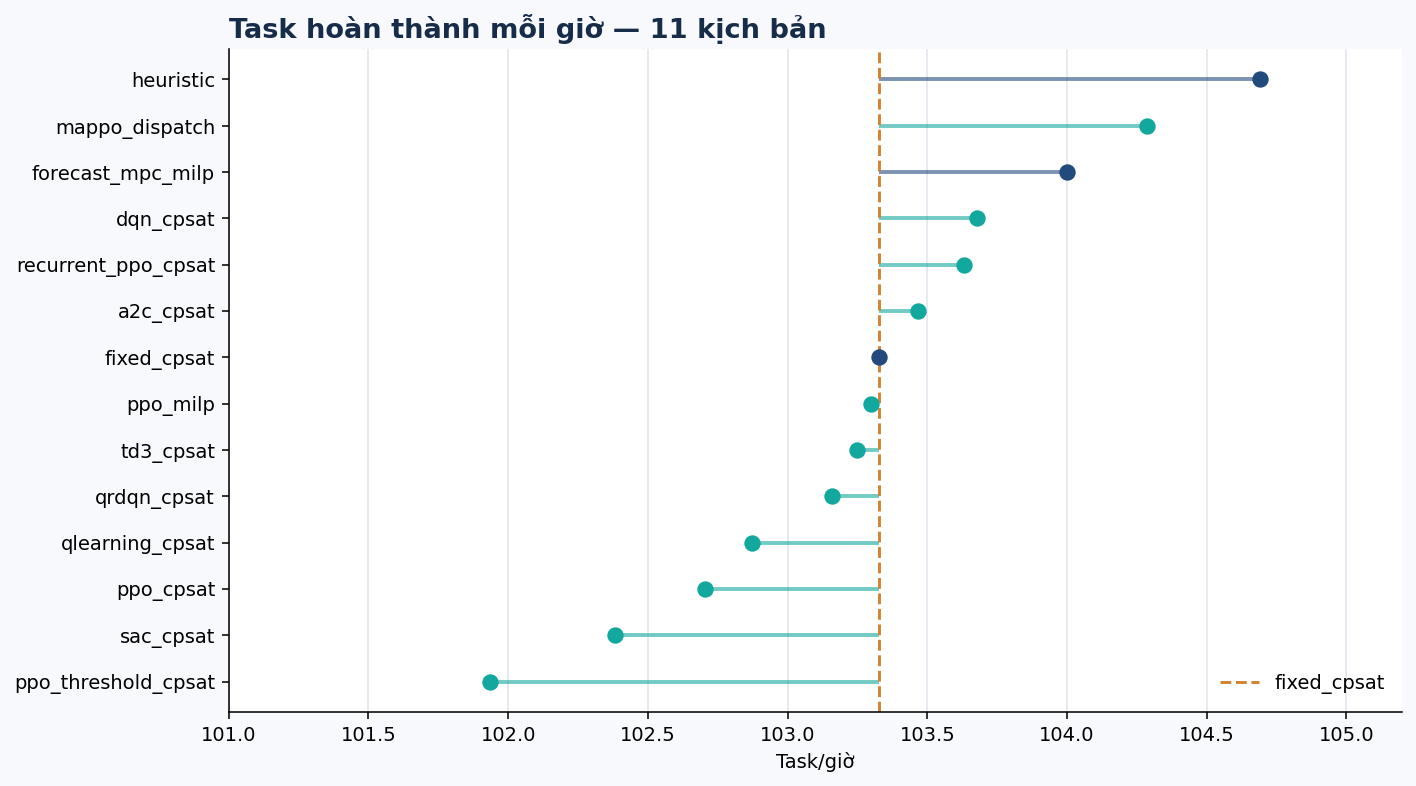

In [4]:
ordered = sorted(comparison, key=lambda row: number(row, 'throughput_per_hour'))
fig, ax = style('Task hoàn thành mỗi giờ — 11 kịch bản', 'Task/giờ')
fixed = next(row for row in comparison if row['method'] == 'fixed_cpsat')
reference = number(fixed, 'throughput_per_hour')
for index, row in enumerate(ordered):
    value = number(row, 'throughput_per_hour')
    color = '#234a7d' if row['method'] in baselines else '#12a89d'
    ax.hlines(index, min(reference, value), max(reference, value), color=color, alpha=0.6, linewidth=2)
    ax.scatter(value, index, color=color, s=55, zorder=3)
ax.set_yticks(range(len(ordered)), [row['method'] for row in ordered])
ax.axvline(reference, color='#d3832f', linestyle='--', label='fixed_cpsat')
ax.legend(frameon=False, loc='lower right')
ax.set_xlim(101, 105.2)
plt.show()


## 3. Độ trễ đơn hàng ngoài S8

**Total lateness** cộng số giây trễ của mọi task đến trong ca; **thấp hơn tốt hơn**. Task chưa xong được tính trễ đến cuối ca, nên đây là chỉ số bị kiểm duyệt phải (right censored). Biểu đồ lấy trung bình đều trên 10 nhóm **S1–S7, S9, OOD_A/B** để nhìn rõ khác biệt vận hành thông thường; S8 được xem riêng ở mục 8.


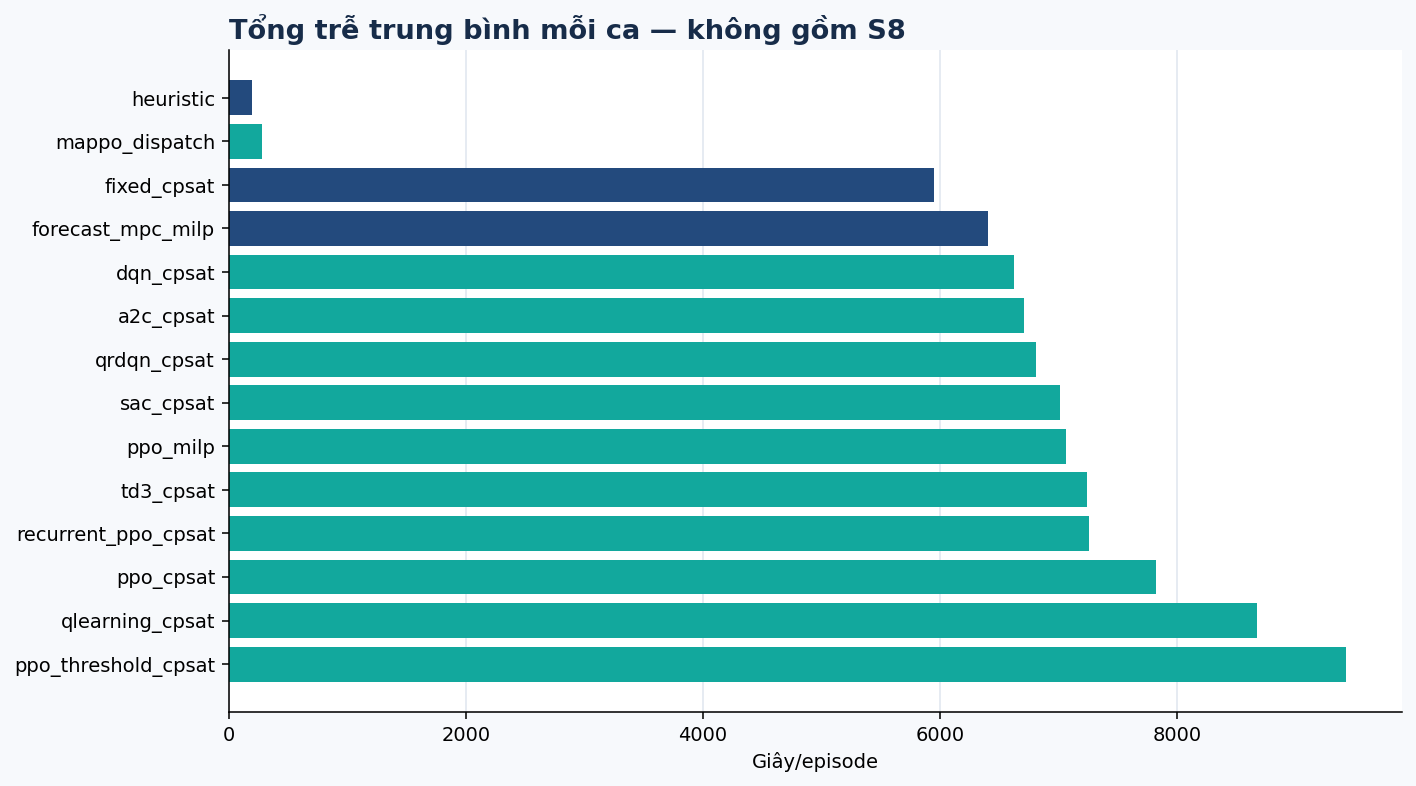

In [5]:
normal_scenarios = [f'S{i}' for i in range(1, 8)] + ['S9', 'OOD_A', 'OOD_B']
lateness = {method: mean(group_mean(method, scenario, 'total_lateness_s')
                         for scenario in normal_scenarios) for method in methods}
ordered_methods = sorted(methods, key=lambda method: lateness[method], reverse=True)
fig, ax = style('Tổng trễ trung bình mỗi ca — không gồm S8', 'Giây/episode')
ax.barh(ordered_methods, [lateness[method] for method in ordered_methods],
        color=['#234a7d' if method in baselines else '#12a89d' for method in ordered_methods])
plt.show()


## 4. Hiệu suất năng lượng

**Wh/task hoàn thành** = điện năng robot tiêu thụ chia cho số task hoàn thành; **thấp hơn tốt hơn** khi chất lượng phục vụ tương đương. Biểu đồ lấy trung bình trên episode hoàn tất; không được đọc một mình vì phương án làm quá ít task có thể tạo tỷ số bất thường.


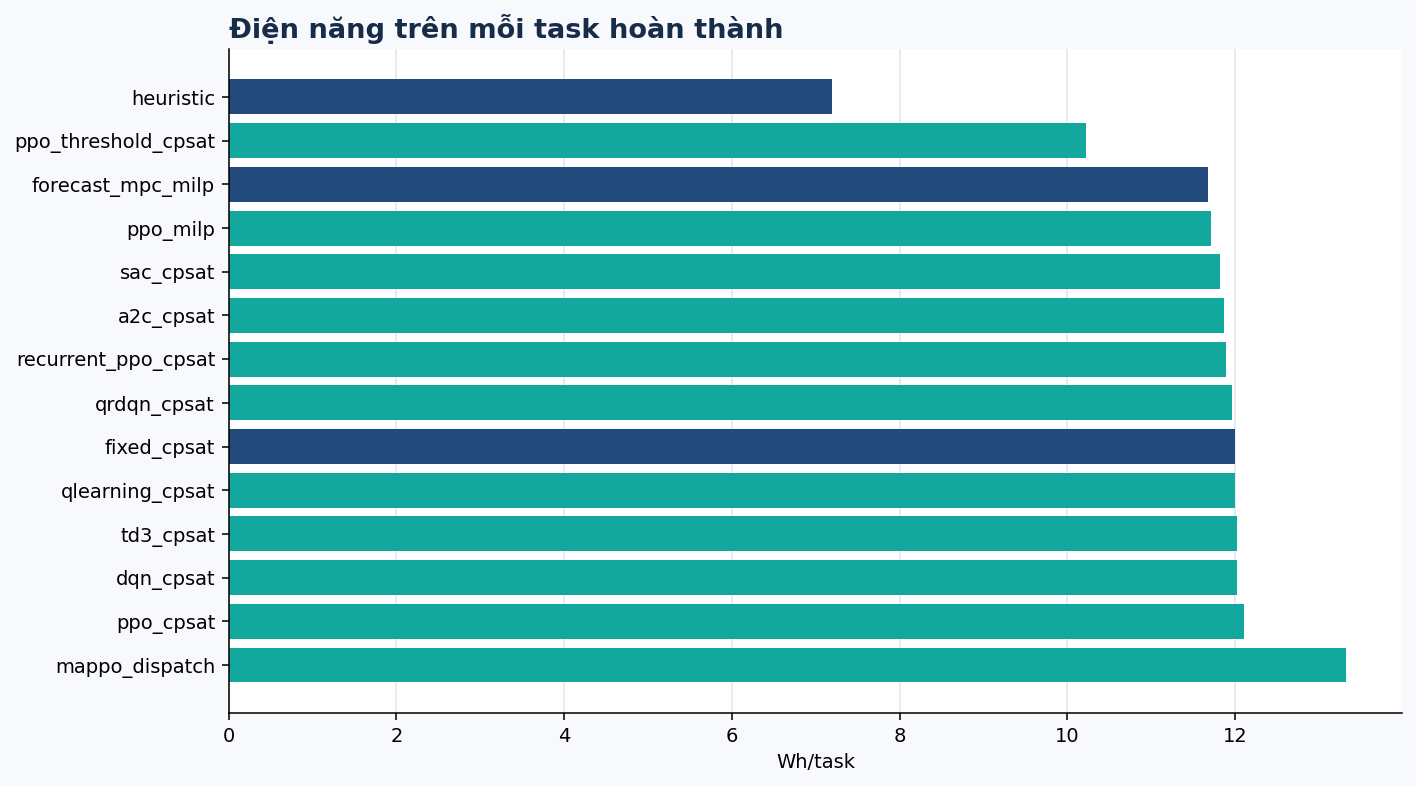

In [6]:
energy = {method: mean(number(row, 'energy_per_completed_wh') for row in episodes
                       if row['method'] == method and row['status'] == 'complete'
                       and number(row, 'energy_per_completed_wh') == number(row, 'energy_per_completed_wh'))
          for method in methods}
ordered_methods = sorted(methods, key=lambda method: energy[method], reverse=True)
fig, ax = style('Điện năng trên mỗi task hoàn thành', 'Wh/task')
ax.barh(ordered_methods, [energy[method] for method in ordered_methods],
        color=['#234a7d' if method in baselines else '#12a89d' for method in ordered_methods])
plt.show()


## 5. Độ trễ ra quyết định

**Decision p95** là ngưỡng mà 95% quyết định không vượt quá; **thấp hơn tốt hơn**. Số ở đây là trung bình p95 theo episode, không phải p95 gộp của mọi lần quyết định. Đây là độ trễ online, khác với thời gian train.


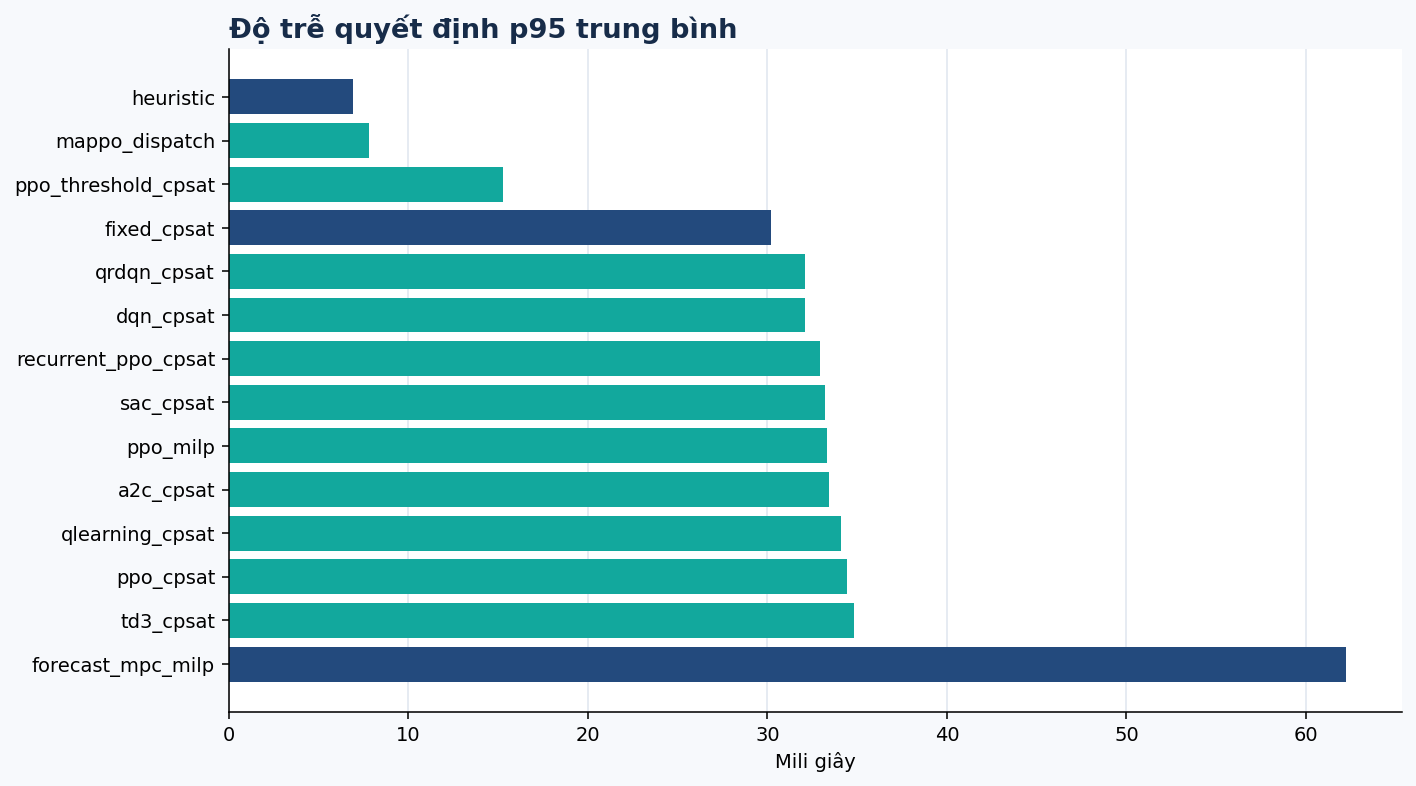

In [7]:
ordered = sorted(comparison, key=lambda row: number(row, 'decision_p95_ms'), reverse=True)
fig, ax = style('Độ trễ quyết định p95 trung bình', 'Mili giây')
ax.barh([row['method'] for row in ordered], [number(row, 'decision_p95_ms') for row in ordered],
        color=['#234a7d' if row['method'] in baselines else '#12a89d' for row in ordered])
plt.show()


## 6. S4–S7: ca vận hành khó

S4: nhu cầu tăng và pin thấp; S5: nhiều robot tải nặng; S6: sạc khó; S7: đường bị chặn. Chỉ hiển thị **4 phương án tiêu biểu** để dễ nhìn: heuristic, fixed CP-SAT (reference), DQN CP-SAT và MAPPO. Hai biểu đồ dưới đây dùng cùng dữ liệu nhưng **tách throughput và lateness** vì đơn vị khác nhau.


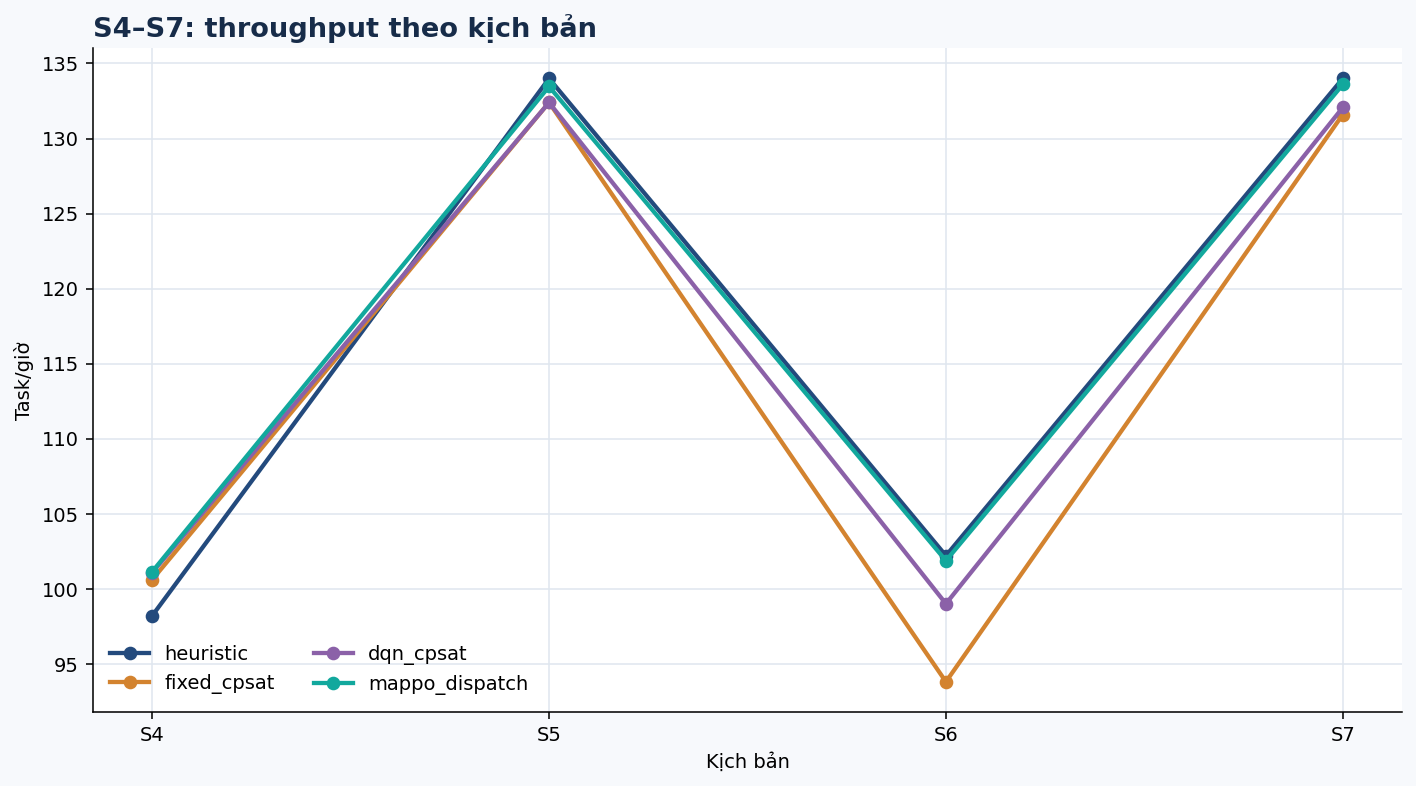

In [8]:
selected = ['heuristic', 'fixed_cpsat', 'dqn_cpsat', 'mappo_dispatch']
colors = {'heuristic': '#234a7d', 'fixed_cpsat': '#d3832f',
          'dqn_cpsat': '#8b61a8', 'mappo_dispatch': '#12a89d'}
stress = ['S4', 'S5', 'S6', 'S7']
fig, ax = style('S4–S7: throughput theo kịch bản', 'Kịch bản', 'Task/giờ')
ax.grid(axis='y', color='#dfe6ef')
for method in selected:
    ax.plot(stress, [group_mean(method, scenario, 'throughput_per_hour') for scenario in stress],
            marker='o', linewidth=2.2, label=method, color=colors[method])
ax.legend(frameon=False, ncol=2)
plt.show()


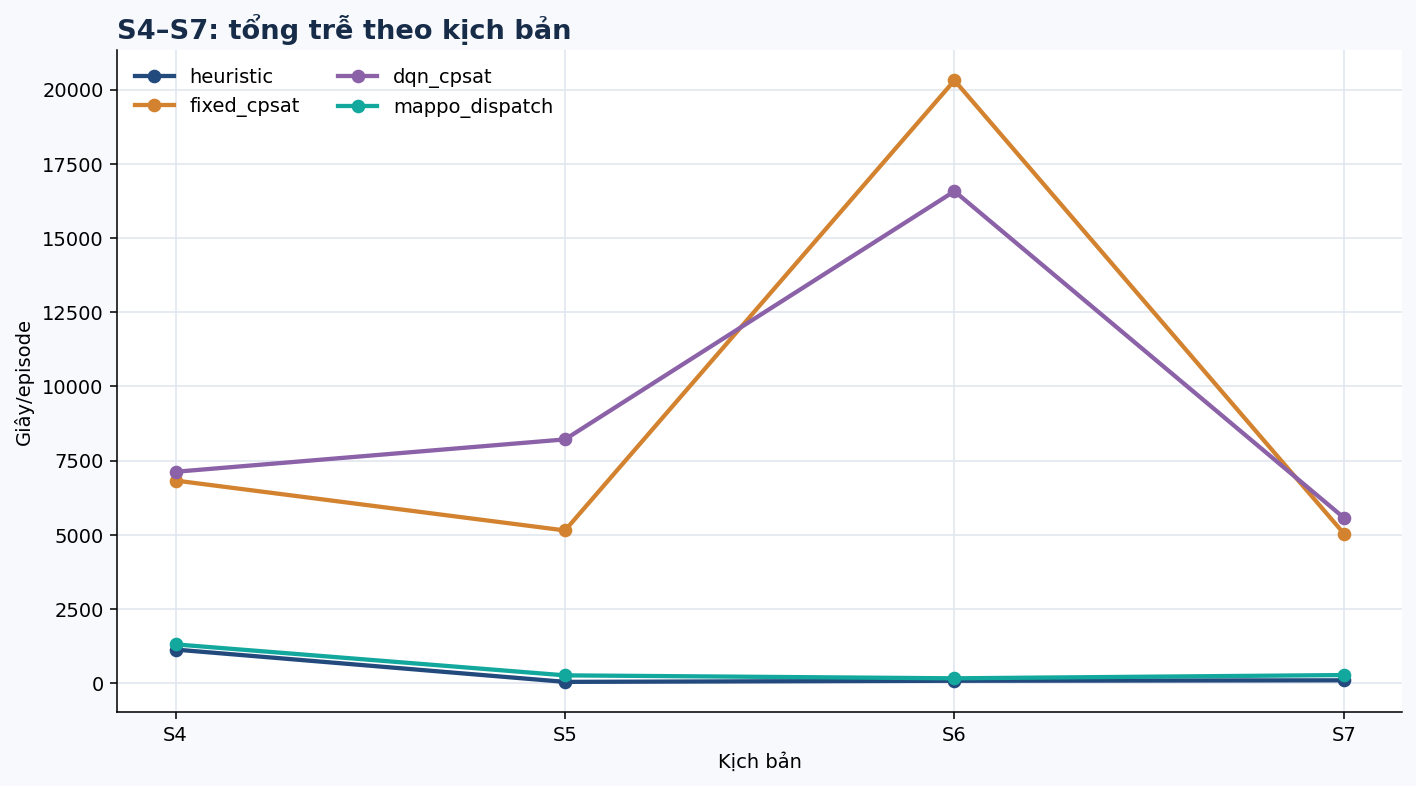

In [9]:
fig, ax = style('S4–S7: tổng trễ theo kịch bản', 'Kịch bản', 'Giây/episode')
ax.grid(axis='y', color='#dfe6ef')
for method in selected:
    ax.plot(stress, [group_mean(method, scenario, 'total_lateness_s') for scenario in stress],
            marker='o', linewidth=2.2, label=method, color=colors[method])
ax.legend(frameon=False, ncol=2)
plt.show()


### Mức chắc chắn của chênh lệch throughput MAPPO so với fixed CP-SAT

Chấm là chênh lệch trung bình **MAPPO − fixed CP-SAT**; thanh ngang là **bootstrap CI95 ghép cặp** từ `summary.json`, ghép cùng task tape và tính biến động giữa checkpoint train. Nếu khoảng cắt qua 0, dữ liệu chưa cho thấy chênh lệch chắc chắn trong kịch bản đó. **Không** cộng các CI đơn lẻ để tuyên bố mục tiêu +5% toàn S4–S7.


Trung bình S4–S7: fixed=114.600, MAPPO=117.517 task/h; tăng 2.55% (mục tiêu 5%).


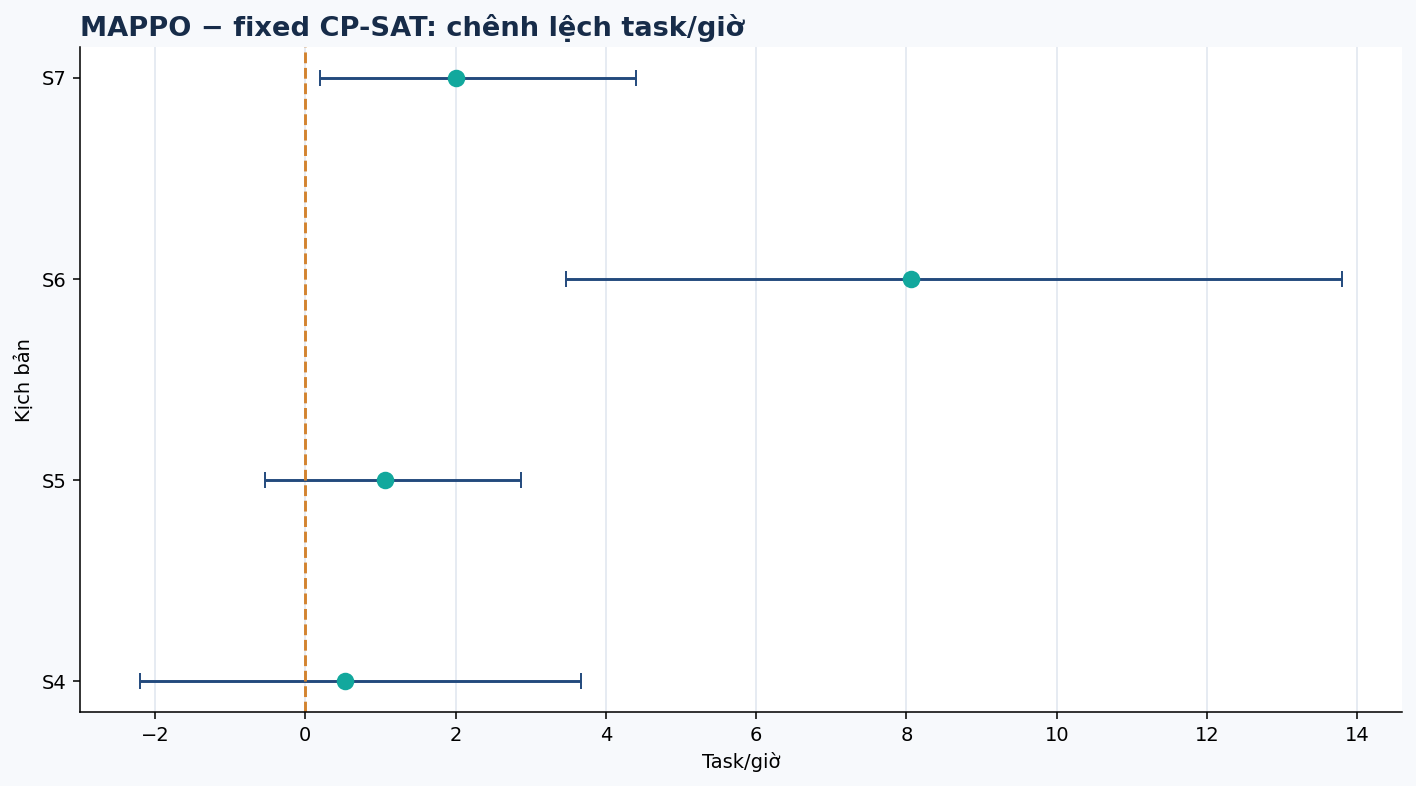

In [10]:
group_lookup = {(group['method'], group['scenario']): group for group in summary['groups']}
paired = [group_lookup[('mappo_dispatch', scenario)]['paired_vs_reference']['throughput_per_hour']
          for scenario in stress]
diff = [entry['mean_difference'] for entry in paired]
lower = [entry['ci95'][0] for entry in paired]
upper = [entry['ci95'][1] for entry in paired]
fig, ax = style('MAPPO − fixed CP-SAT: chênh lệch task/giờ', 'Task/giờ', 'Kịch bản')
ax.errorbar(diff, stress, xerr=[[value - low for value, low in zip(diff, lower)],
                                 [high - value for value, high in zip(diff, upper)]],
            fmt='o', color='#12a89d', ecolor='#234a7d', capsize=4, markersize=8)
ax.axvline(0, color='#d3832f', linestyle='--')
plt.show()
fixed_stress = mean(group_mean('fixed_cpsat', scenario, 'throughput_per_hour') for scenario in stress)
mappo_stress = mean(group_mean('mappo_dispatch', scenario, 'throughput_per_hour') for scenario in stress)
print(f'Trung bình S4–S7: fixed={fixed_stress:.3f}, MAPPO={mappo_stress:.3f} task/h; '
      f'tăng {(mappo_stress / fixed_stress - 1) * 100:.2f}% (mục tiêu 5%).')


## 7. An toàn

**Safety incident** là lỗi trạng thái hoặc sự cố vật lý được audit; mục tiêu là **0**. Biểu đồ cho thấy **tỷ lệ episode có ít nhất một incident**, để 55 episode của baseline và 165 episode của phương án train vẫn đọc được trên cùng trục. Trung bình incident thấp không bảo đảm mọi lần chạy đều an toàn.


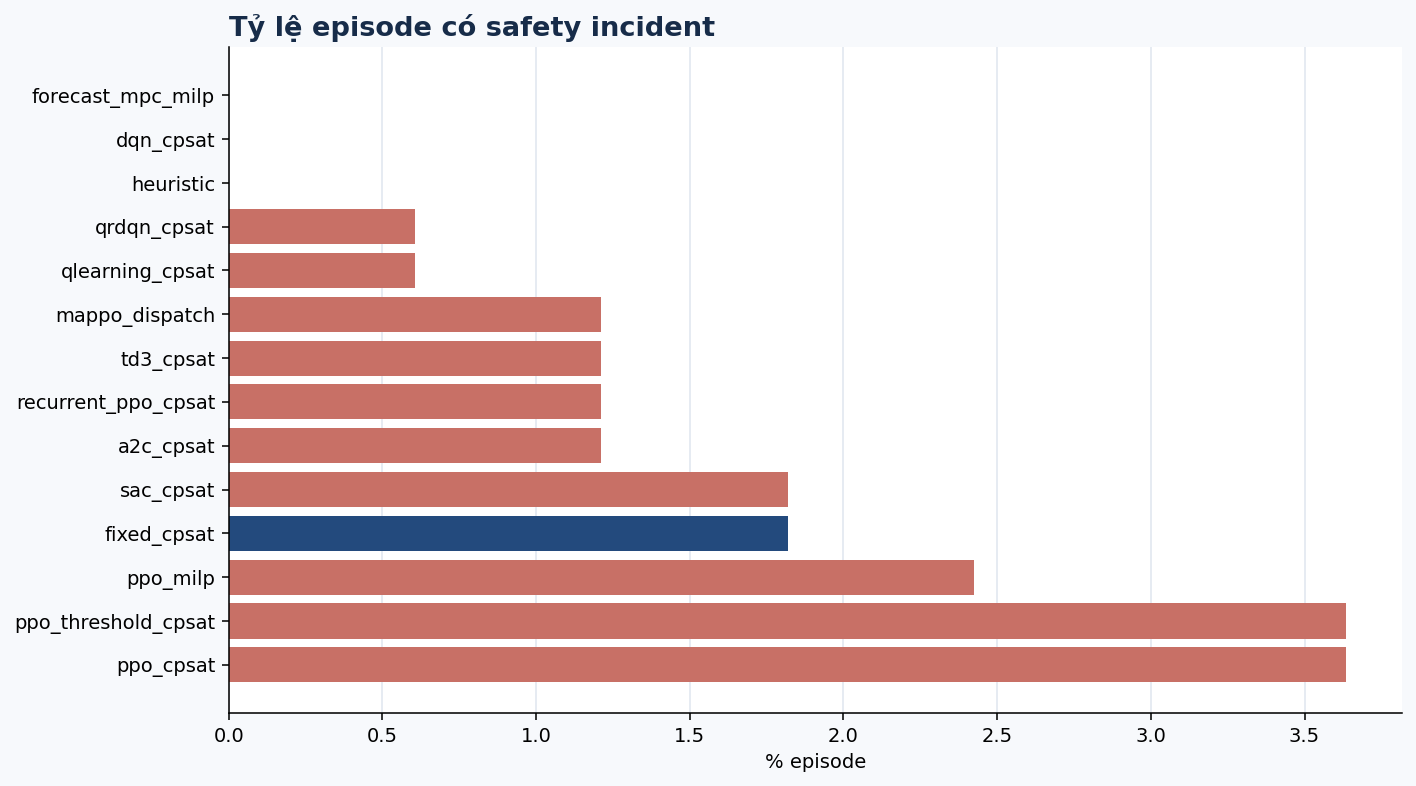

In [11]:
incident_rate = {method: 100 * mean(number(row, 'safety_incidents') > 0 for row in episodes
                                    if row['method'] == method) for method in methods}
ordered_methods = sorted(methods, key=lambda method: incident_rate[method], reverse=True)
fig, ax = style('Tỷ lệ episode có safety incident', '% episode')
ax.barh(ordered_methods, [incident_rate[method] for method in ordered_methods],
        color=['#234a7d' if method in baselines else '#c87066' for method in ordered_methods])
plt.show()


## 8. S8: snapshot trạng thái trễ 15 giây

**Completion rate** = task xong / task đến; **cao hơn tốt hơn**. S8 là ca kiểm thử dữ liệu cũ, không nên trộn vào biểu đồ kịch bản bình thường vì mọi phương án đều suy giảm cực mạnh. MAPPO chỉ hoàn thành khoảng 3% task; đây là rủi ro vận hành cần xử lý trước khi triển khai trong điều kiện tương tự.


heuristic           :  7.80 task/h; pending  96.20
fixed_cpsat         :  7.60 task/h; pending  96.40
dqn_cpsat           :  7.60 task/h; pending  96.40
ppo_milp            :  7.93 task/h; pending  96.07
mappo_dispatch      :  3.20 task/h; pending 100.80


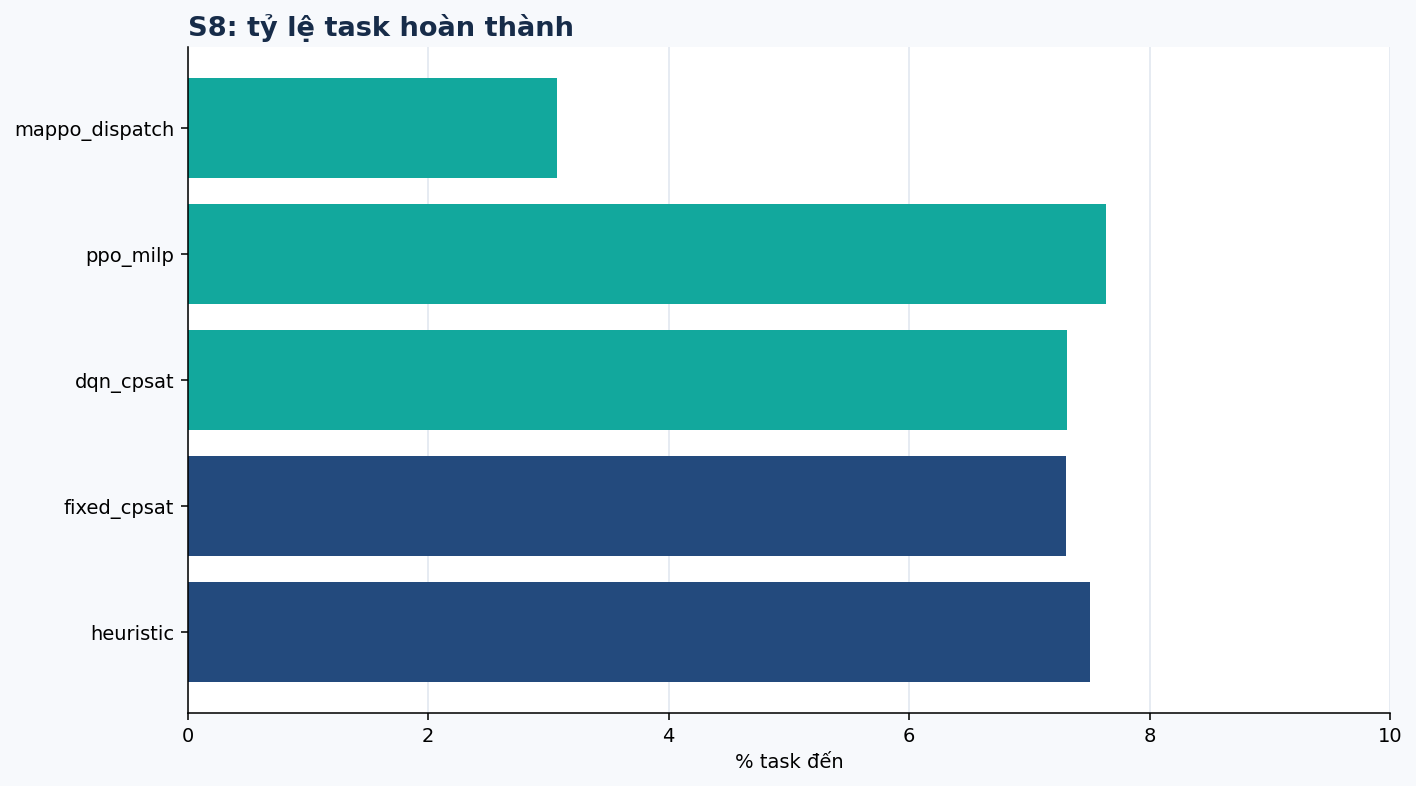

In [12]:
s8_methods = ['heuristic', 'fixed_cpsat', 'dqn_cpsat', 'ppo_milp', 'mappo_dispatch']
fig, ax = style('S8: tỷ lệ task hoàn thành', '% task đến')
ax.barh(s8_methods, [100 * group_mean(method, 'S8', 'completion_rate') for method in s8_methods],
        color=['#234a7d' if method in baselines else '#12a89d' for method in s8_methods])
ax.set_xlim(0, 10)
plt.show()
for method in s8_methods:
    print(f"{method:20}: {group_mean(method, 'S8', 'throughput_per_hour'):5.2f} task/h; "
          f"pending {group_mean(method, 'S8', 'pending'):6.2f}")


## 9. Đổi layout: OOD_B so với OOD_A

Hai ca dùng **cùng task tape**, chủ yếu khác layout; trục là chênh lệch throughput `OOD_B − OOD_A`. Số dương nghĩa layout B tốt hơn trong dữ liệu này. Đây là mô tả ghép cặp, không phải bằng chứng tổng quát rằng thuật toán thích nghi tốt với mọi kho mới. S9 còn thay cả burst và layout nên không dùng để cô lập tác động layout.


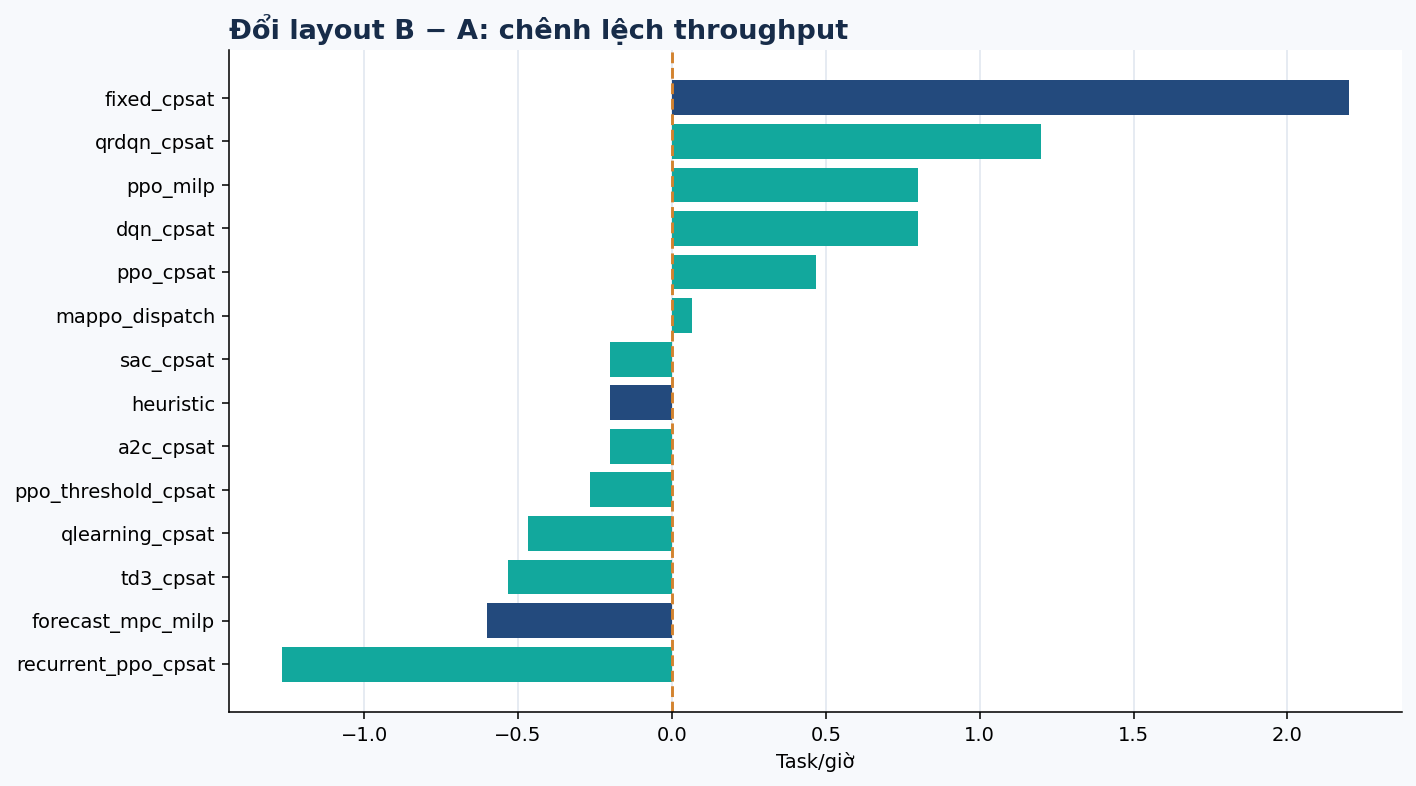

In [13]:
ood = {entry['method']: entry['difference']['mean'] for entry in summary['generalization']
       if entry['metric'] == 'throughput_per_hour' and entry['control'] == 'OOD_A'
       and entry['ood'] == 'OOD_B'}
ordered_methods = sorted(ood, key=ood.get)
fig, ax = style('Đổi layout B − A: chênh lệch throughput', 'Task/giờ')
ax.barh(ordered_methods, [ood[method] for method in ordered_methods],
        color=['#234a7d' if method in baselines else '#12a89d' for method in ordered_methods])
ax.axvline(0, color='#d3832f', linestyle='--')
plt.show()


## 10. Tài nguyên train

**Training steps** là tổng bước của 3 seed; **wall time** là tổng thời gian train ghi nhận trong artifact, không phải thời gian inference. Khác biệt wall time còn do thuật toán, môi trường, lần resume và phần tính toán CPU/solver, nên không dùng làm điểm chất lượng policy.


Tổng bước train chính theo artifact: 9,909,696


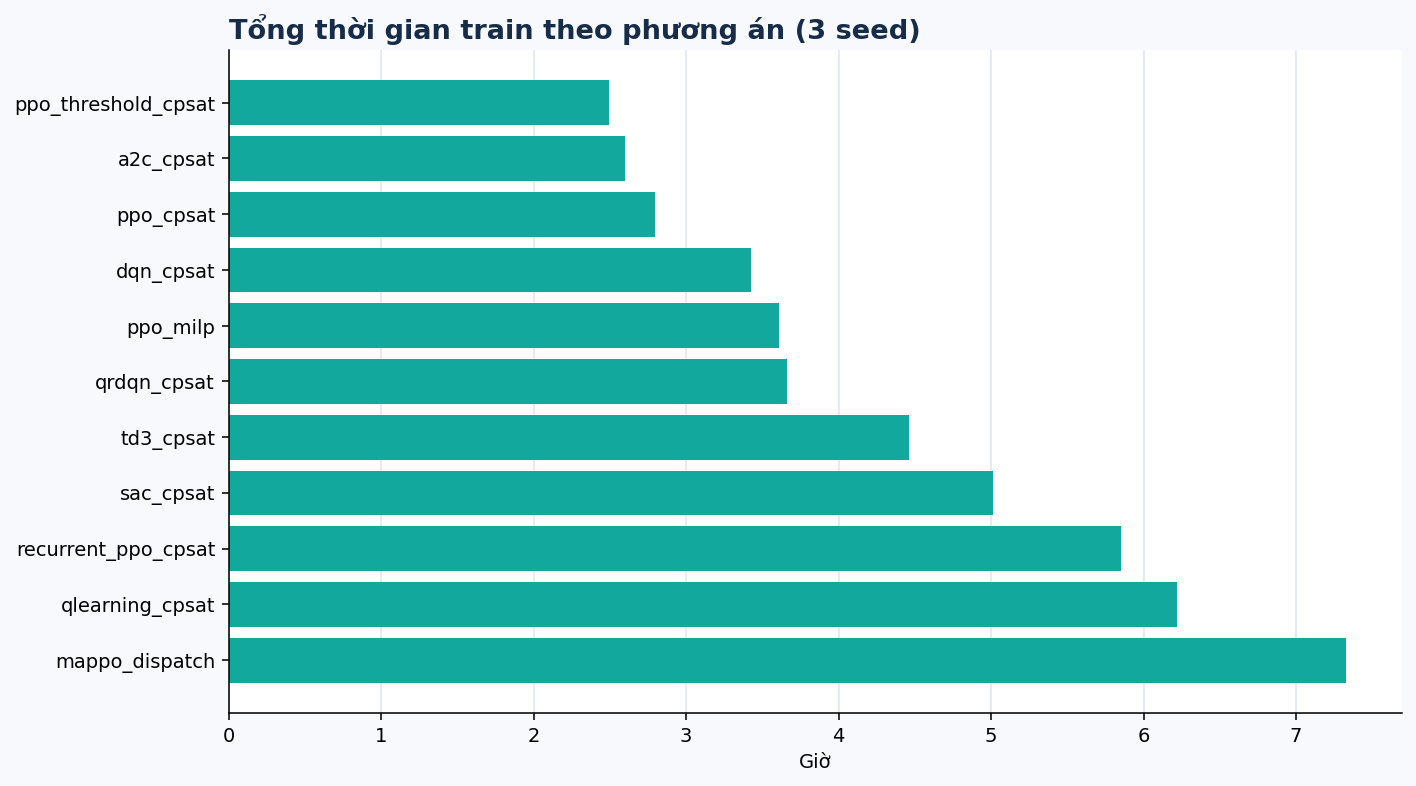

In [14]:
learned = [row for row in comparison if row['method'] not in baselines]
ordered = sorted(learned, key=lambda row: number(row, 'training_wall_s'), reverse=True)
fig, ax = style('Tổng thời gian train theo phương án (3 seed)', 'Giờ')
ax.barh([row['method'] for row in ordered],
        [number(row, 'training_wall_s') / 3600 for row in ordered], color='#12a89d')
plt.show()
print('Tổng bước train chính theo artifact:',
      f"{sum(number(row, 'training_steps') for row in learned):,.0f}")


## 11. Reward trong lúc train: đọc theo từng thuật toán

Các đường dưới đây lấy `rollout/ep_rew_mean` từ `progress.csv` của **DQN, A2C, PPO**; mỗi hình chỉ có 3 training seed của **cùng một thuật toán**. Đường được làm mượt bằng trung bình trượt 7 điểm để dễ nhìn. Reward phụ thuộc định nghĩa và curriculum, không cùng đơn vị với task/h; **không so trực tiếp độ cao reward giữa các thuật toán**, và đường tăng không tự chứng minh hội tụ. MAPPO không có `progress.csv` trong artifact Study14 nên không vẽ reward train giả định; kết quả kiểm thử MAPPO vẫn có ở trên.


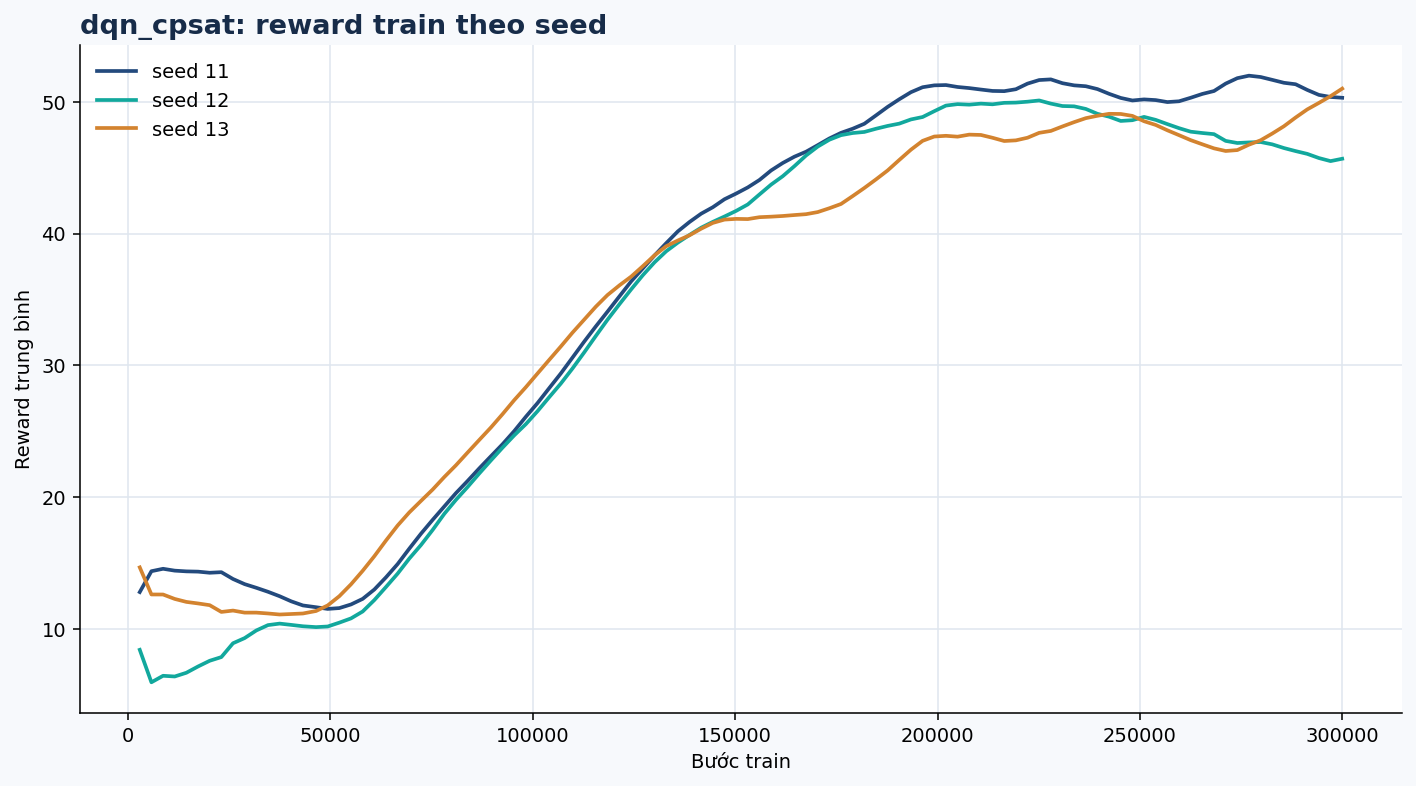

In [15]:
def training_curve(method: str, seed: int) -> tuple[list[float], list[float]]:
    job = study / 'jobs' / f'train_{method}_{seed}'
    points: list[tuple[float, float]] = []
    for path in sorted(job.glob('attempt_*/logs/progress.csv')):
        for row in read_csv(path):
            step = number(row, 'time/total_timesteps')
            reward = number(row, 'rollout/ep_rew_mean')
            if step == step and reward == reward:
                points.append((step, reward))
    points.sort()
    return [point[0] for point in points], [point[1] for point in points]

def smooth(values: list[float], width: int = 7) -> list[float]:
    return [mean(values[max(0, index - width + 1):index + 1])
            for index in range(len(values))]

def plot_reward(method: str) -> None:
    fig, ax = style(f'{method}: reward train theo seed', 'Bước train', 'Reward trung bình')
    ax.grid(axis='y', color='#dfe6ef')
    for seed, color in zip((11, 12, 13), ('#234a7d', '#12a89d', '#d3832f')):
        steps, rewards = training_curve(method, seed)
        if steps:
            ax.plot(steps, smooth(rewards), label=f'seed {seed}', color=color, linewidth=1.9)
    ax.legend(frameon=False)
    plt.show()

plot_reward('dqn_cpsat')


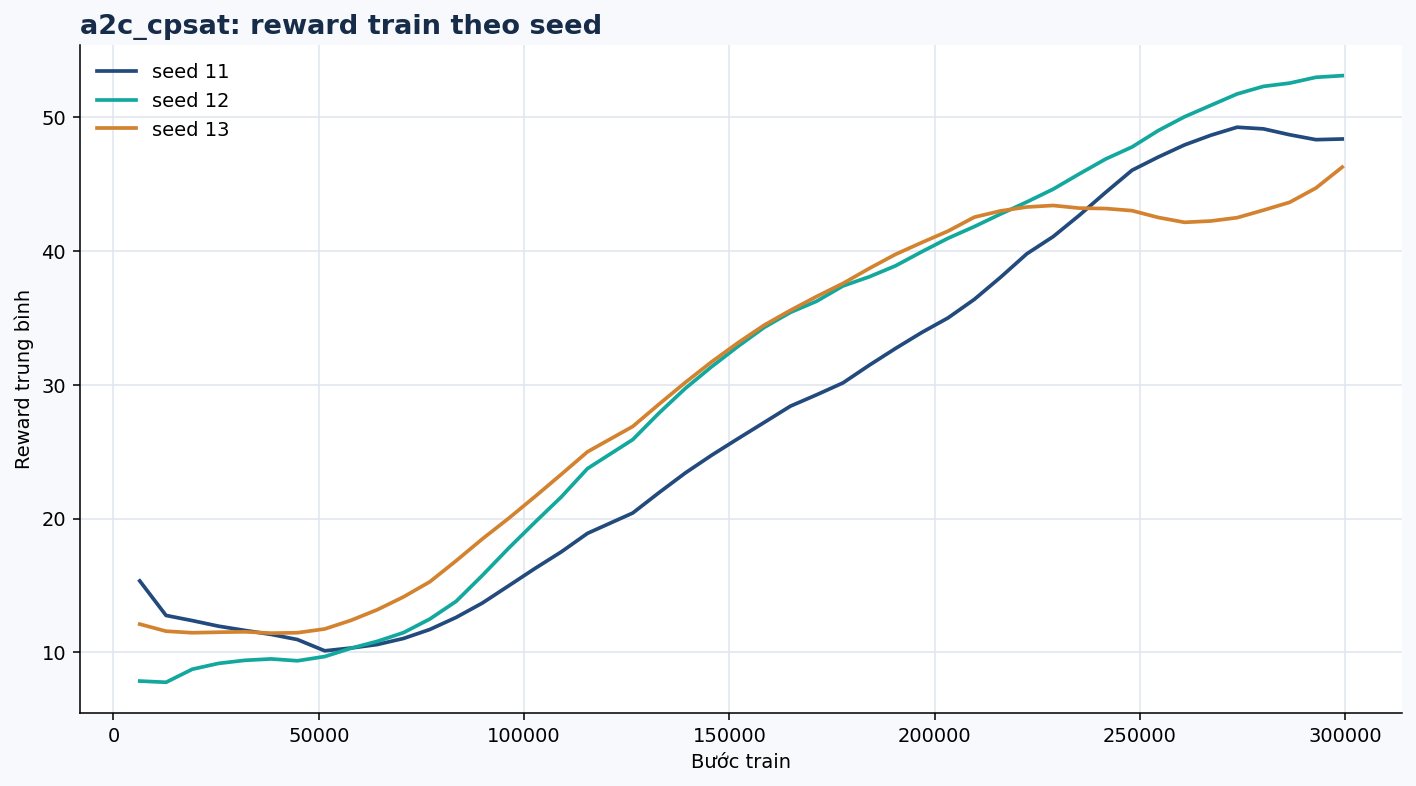

In [16]:
plot_reward('a2c_cpsat')


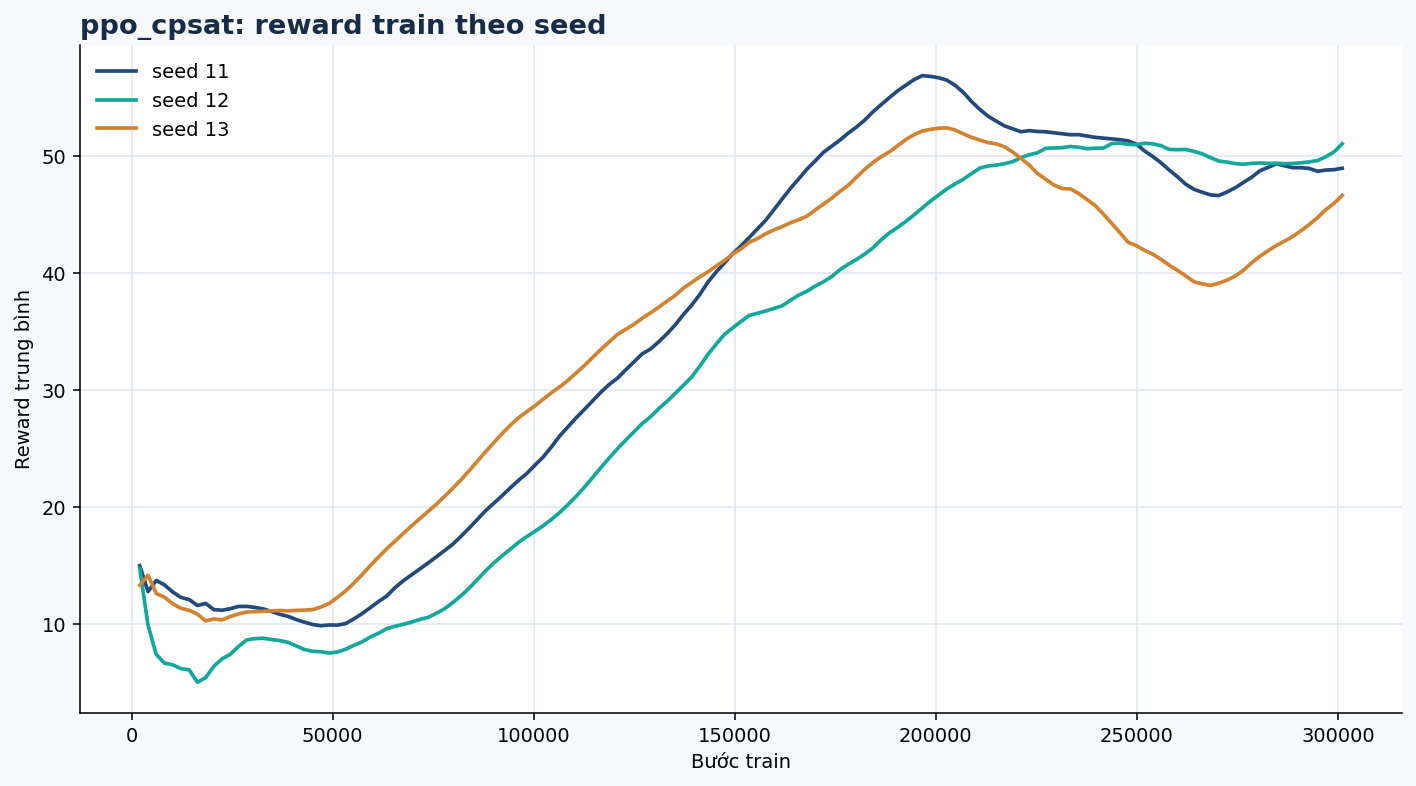

In [17]:
plot_reward('ppo_cpsat')


## 12. Kết luận thực nghiệm và giới hạn

1. **Training và kiểm thử đã hoàn tất:** 33 job train chính, 1.980/1.980 episode. Dữ liệu cho phép so sánh mô tả; số bước đầy đủ không chứng minh hội tụ.
2. **Heuristic vẫn là mốc mạnh:** throughput toàn bộ cao nhất và safety incident bằng 0 trong study này. MAPPO là phương án có học nổi bật nhất về tổng thể, nhưng chưa chứng minh vượt heuristic toàn diện.
3. **MAPPO so với fixed CP-SAT trên S4–S7:** throughput tăng khoảng **2,55%**, chưa đạt giả thuyết **≥5%**. Nó giảm rất mạnh lateness và pending, đặc biệt ở S6. CI của S4/S5 cắt 0, nên không kết luận tăng throughput ở mọi ca khó.
4. **S8 là điểm yếu hệ thống:** dữ liệu trạng thái trễ 15 giây khiến tất cả phương án xử lý dưới 8% task; MAPPO còn thấp hơn. Cần xử lý freshness/fallback trước khi xem xét triển khai.
5. **Nguồn train có migration:** giữa study đã sửa lỗi nested deadlock recovery; checkpoint có thể được tạo trước hoặc sau sửa. Xem `runs/study14/source_migration.json`. Biểu đồ reward chỉ là log train có sẵn; quyết định chọn mô hình nên dựa thêm trên test ghép cặp, an toàn, năng lượng và độ trễ online.

**Từ điển ngắn:** `pending` = task còn chưa xong cuối ca (thấp hơn tốt hơn); `lateness` = tổng giây trễ (thấp hơn); `completion_rate` = tỷ lệ hoàn thành (cao hơn); `safety_incidents` = số sự cố (mục tiêu 0); `p95` = ngưỡng 95% quan sát không vượt qua (thấp hơn cho latency). Định nghĩa đầy đủ M01–M16 nằm ở `runs/study14/metrics_dictionary.md`.
